### nxsut generator

Run this code to generate (or update) our nxsut reference database.
By default, it relies on Exiobase Hybrid version (v3.3.18) but could be potentially arranged to any other SUT in the future. 

As if 5th November 2024, the above-mentioned database is parsed, aggregated in terms of electricity commodity (1 commodity) and activities (EMBER power plants technologies) and electricity production mixes are updated according to EMBER ones for a given year.

Just mind to update your paths in the 'paths.yml' file and to specify the user (your initials) and the desired electricity mix in the first cell, then run all the code

In [ ]:
import mario
import yaml
import pandas as pd
from support.ember_remapping import map_ember_to_classification

user = 'LR'   # change this to your username
year = 2024   # change this to the year you want to update the electricity mixes to

with open('paths.yml', 'r') as file: # open the yml file
    paths = yaml.safe_load(file)

paths = paths[user]

In [ ]:
# Parse raw SUT
world = mario.parse_from_txt(paths['raw'], table='SUT', mode='flows')

In [ ]:
# Aggregate electricity commodities and activities to match EMBER
world.aggregate("support/aggregate_ee.xlsx",ignore_nan=True)

In [ ]:
# Parse ember electricity generation data, map to exiobase and get electricity mix for a given year 
ee_mix = map_ember_to_classification(
    path = paths['ember'],
    classification = 'EXIO3',
    year = None,
    mode = 'mix',
)

In [ ]:
z = world.z
s = world.s
region = 'IN'
region_latest_year = ee_mix.loc[(region,slice(None),slice(None))].index.get_level_values(0).max()


In [ ]:
ee_mix.loc[(region,region_latest_year,slice(None)),'Value'].to_frame().sort_index(axis=0)

In [ ]:
#%% Update electricity mixes
z = world.z
s = world.s

for region in world.get_index('Region'):
    print(region,end=' ')
    region_latest_year = ee_mix.loc[(region,slice(None),slice(None))].index.get_level_values(0).max()
    new_mix = ee_mix.loc[(region,region_latest_year,slice(None)),'Value'].to_frame().sort_index(axis=0)
    # new_mix = ee_mix.loc[(region,slice(None),slice(None)),'Value'].to_frame().sort_index(axis=0) 
    new_mix.index = new_mix.index.get_level_values(2)
    old_market_share = s.loc[(region, 'Activity', new_mix.index),(region,'Commodity','Electricity')].sum().sum()
    
    s.loc[(region, 'Activity', new_mix.index),(region,'Commodity','Electricity')] = new_mix.values*old_market_share # check if commodity electricity is called "Electricity" in aggregation excel file
    # s.loc[:,(region,'Commodity','Electricity')] /= s.loc[:,(region,'Commodity','Electricity')].sum()
    print('done')

z.update(s)

world.update_scenarios('baseline',z=z)
world.reset_to_coefficients('baseline')

In [ ]:
world.to_txt(paths['export']+f"/{year}")

In [ ]:
ghgs = {
    'Carbon dioxide, fossil (air - Emiss)':1,
    'CH4 (air - Emiss)':29,
    'N2O (air - Emiss)':273
    }

f = world.f.loc[ghgs.keys(),(slice(None),'Commodity','Electricity')]
if isinstance(f,pd.Series):
    f = f.to_frame()

for ghg,gwp in ghgs.items():
    f.loc[ghg,:] *= gwp

f = f.sum(0)*3.6
f = f.to_frame()
f.columns = ['Value']
f.reset_index(inplace = True)
f = f.drop("Level",axis=1)



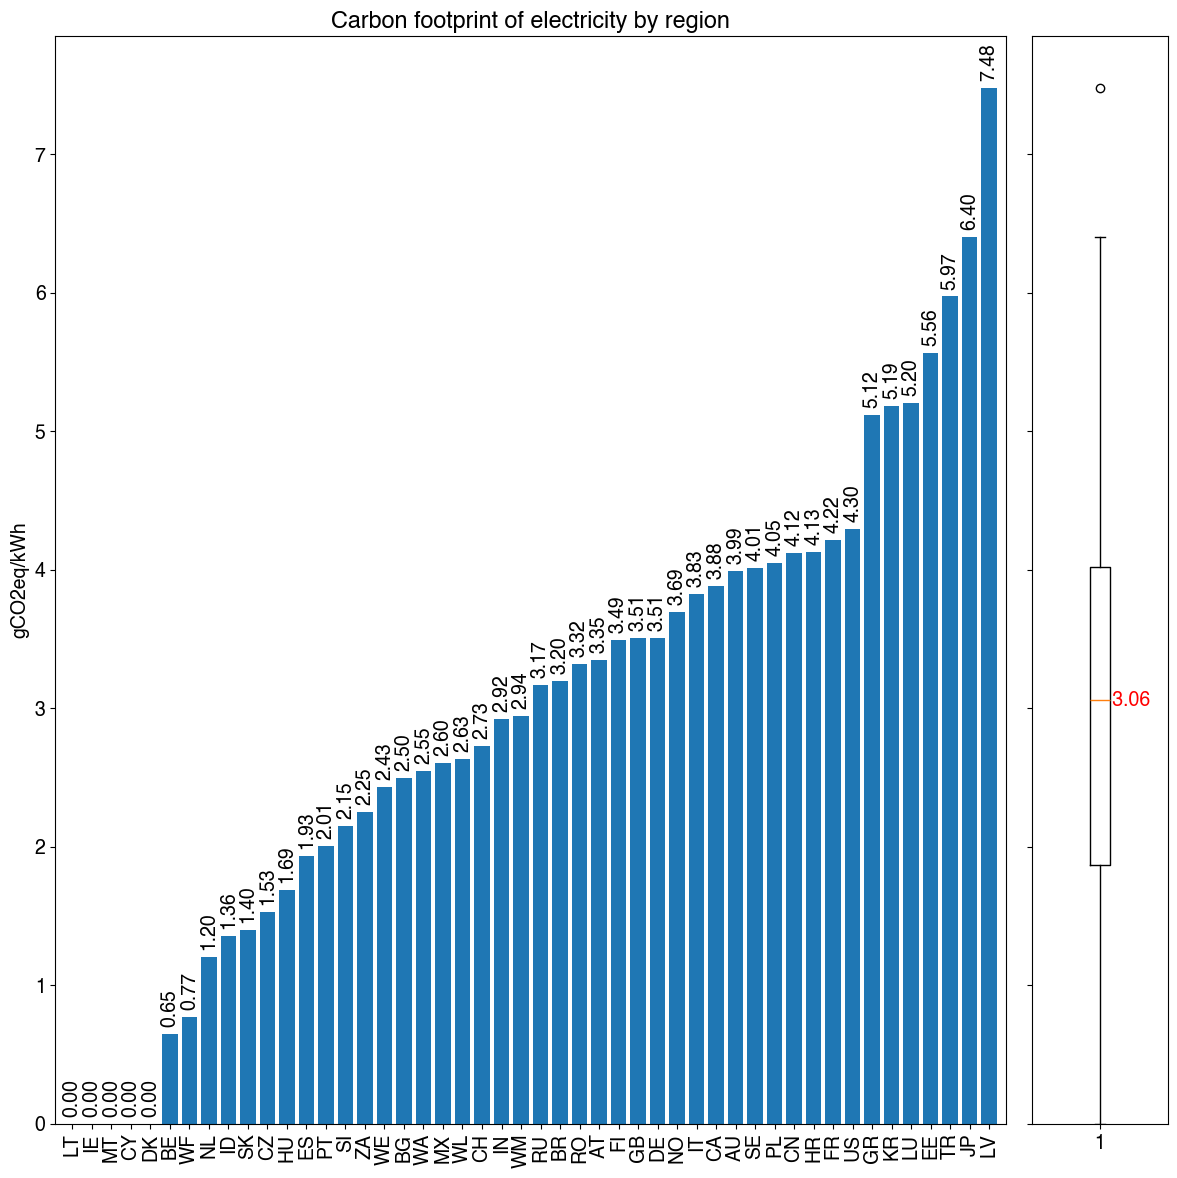

In [158]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 12), gridspec_kw={'width_ratios': [7, 1]}, sharey=True)

# First subplot: Bar chart
# Sort the dataframe by 'Value' in descending order
f_sorted = f.sort_values(by='Value', ascending=True)
bars = axs[0].bar(f_sorted['Region'], f_sorted['Value'], orientation='vertical')
# Remove margins
axs[0].margins(x=0.01)

# Set max y limit
# axs[0].set_ylim(0, 1200)
# Add data labels to the bars
for bar in bars:
    height = bar.get_height()
    axs[0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=90)

# Add median line to the boxplot
median = f['Value'].median()
# axs[1].axhline(median, color='r', linestyle='--')
axs[1].annotate(f' {median:.2f}',
                xy=(1, median),
                xytext=(5, 0),  # 5 points horizontal offset
                textcoords="offset points",
                ha='left', va='center', color='r')
axs[0].set_title('Carbon footprint of electricity by region')
# axs[0].set_xlabel('Region')
axs[0].set_ylabel('gCO2eq/kWh')
axs[0].tick_params(axis='x', rotation=90)

# Second subplot: Boxplot
axs[1].boxplot(f['Value'])
# Increase fontsize of all texts in the figure
plt.rcParams.update({'font.size': 14, 'font.family': 'Helvetica'})
# axs[1].set_ylabel('gCO2eq/kWh')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
ee_prod = world.s.loc[:,('IT','Commodity','Electricity')]
ee_prod = ee_prod.to_frame()
ee_prod.columns = ['EE_market_share']
ee_prod = ee_prod.query('EE_market_share>0')
ee_prod.sort_values('EE_market_share',ascending=False,inplace=True)
ee_prod


ghgs = {
    'Carbon dioxide, fossil (air - Emiss)':1,
    'CH4 (air - Emiss)':29,
    'N2O (air - Emiss)':273
    }

f = world.f.loc[ghgs.keys(),('IT','Activity',ee_prod.index.get_level_values(2))]
if isinstance(f,pd.Series):
    f = f.to_frame()

for ghg,gwp in ghgs.items():
    f.loc[ghg,:] *= gwp

f = f.sum(0)*3.6
f = f.droplevel(0)
f = f.droplevel(0)
f = f.to_frame()
f.columns = ['gCO2eq/kWh']

ee_prod = ee_prod.join(f)
ee_prod.to_clipboard()

In [194]:
ghgs = {
    'Carbon dioxide, fossil (air - Emiss)':1,
    'CH4 (air - Emiss)':29,
    'N2O (air - Emiss)':273
    }

f = world.f.loc[ghgs.keys(),(slice(None),'Activity',['Coal','Gas','Other Fossil','Nuclear','Hydro','Bioenergy','Solar','Wind','Other Renewables'])]
if isinstance(f,pd.Series):
    f = f.to_frame()

for ghg,gwp in ghgs.items():
    f.loc[ghg,:] *= gwp

f = f.sum(0)*3.6
f = f.to_frame()
f.columns = ['Value']
f.reset_index(inplace = True)
f = f.drop("Level",axis=1)

In [ ]:
import numpy as np
from copy import deepcopy
ghgs = {
    'Carbon dioxide, fossil (air - Emiss)':1,
    'CH4 (air - Emiss)':29,
    'N2O (air - Emiss)':273
    }

f_ex_ghg = {}
for ghg,gwp in ghgs.items():
    print(ghg)
    f_ex = np.diagflat(world.e.loc[ghg,:].values) @ world.w.values
    f_ex *= gwp*3.6
    f_ex = pd.DataFrame(f_ex,columns=world.e.columns,index=world.e.columns)
    f_ex_ghg[ghg] = f_ex

f_ex_ghg['GHGs'] = sum(f_ex_ghg.values())

Carbon dioxide, fossil (air - Emiss)
CH4 (air - Emiss)
N2O (air - Emiss)


In [232]:
f_ex_ghg['GHGs'].loc[:,(['GB','IT'],'Commodity','Natural gas and services related to natural gas extraction; excluding surveying')].to_clipboard()
# f_ex_ghg['GHGs'].loc[:,(slice(None),'Activity','Gas')].sum(0).sort_values(ascending=False)

In [228]:
world.search('Commodity','gas')

['Oxygen Steel Furnace Gas',
 'Gasoline Type Jet Fuel',
 'Blast Furnace Gas',
 'Sewage sludge for treatment: biogasification and land application',
 'Distribution services of gaseous fuels through mains',
 'Gas Works Gas',
 'Biogas',
 'Motor Gasoline',
 'Gas/Diesel Oil',
 'Refinery Gas',
 'Food waste for treatment: biogasification and land application',
 'Paper waste for treatment: biogasification and land application',
 'Natural Gas Liquids',
 'Biogasoline',
 'Coke oven gas',
 'Aviation Gasoline',
 'Liquefied Petroleum Gases (LPG)',
 'Natural gas and services related to natural gas extraction; excluding surveying',
 'Gas Coke',
 'Manure (biogas treatment)']

In [231]:
(world.u.loc[(slice(None),'Commodity',['Blast Furnace Gas','Natural gas and services related to natural gas extraction; excluding surveying','Oxygen Steel Furnace Gas']),(slice(None),'Activity','Gas')]*3.6).groupby(level=2,axis=0).sum().T.to_clipboard()

/var/folders/7_/vg3_ld6n2pd73xyzt9dcdhlc0000gn/T/ipykernel_40041/3913431726.py:1: FutureWarning:

The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.



<Figure size 1200x1200 with 0 Axes>

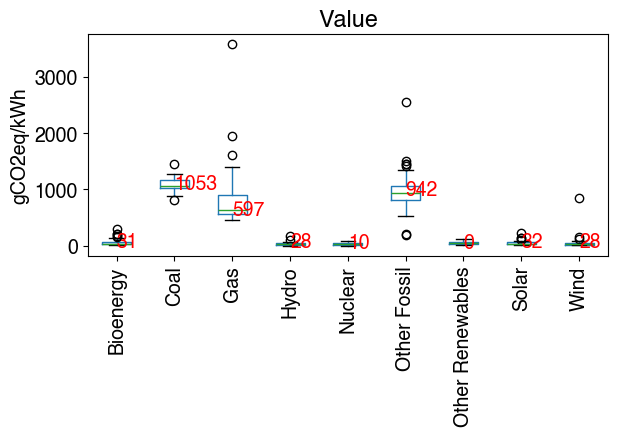

In [195]:
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(12, 12))
# Remove rows where "Value" is 0
f_non_zero = f[f['Value'] != 0]

# Create a box plot
boxplot = f_non_zero.boxplot(column='Value', by='Item', grid=False, rot=90, showfliers=True)

# Add median data label to each boxplot
medians = f.groupby('Item')['Value'].median()
for i, median in enumerate(medians, start=1):
    plt.text(i, median + 50, f'{median:.0f}', horizontalalignment='center', color='red', weight='semibold', va='center', ha='left')

# Set the title and labels
plt.suptitle(None)
plt.ylabel('gCO2eq/kWh')
plt.xlabel(None)

# Show the plot
plt.tight_layout()
plt.rcParams.update({'font.size': 10, 'font.family': 'Helvetica'})

plt.show()

In [197]:
f.query("Item=='Gas'").sort_values('Value',ascending=False)

,Region,Item,Value
62,FI,Gas,3575.079741
85,SE,Gas,1948.226269
73,KR,Gas,1616.227445
48,AT,Gas,1391.998117
58,DE,Gas,1270.667110
63,FR,Gas,1179.907019
55,CN,Gas,1122.890303
52,BR,Gas,1051.194312
72,JP,Gas,1050.064128
81,PL,Gas,993.269743


In [183]:
world.search("Activity","Steel")

['Manufacture of basic iron and steel and of ferro-alloys and first products thereof',
 'Re-processing of secondary steel into new steel']

In [190]:
ghgs = {
    'Carbon dioxide, fossil (air - Emiss)':1,
    'CH4 (air - Emiss)':29,
    'N2O (air - Emiss)':273
    }

f = world.f.loc[
    ghgs.keys(),
    (slice(None),'Commodity',[
        'Basic iron and steel and of ferro-alloys and first products thereof',
        'Aluminium and aluminium products',
        'Cement; lime and plaster',
        'Chemicals nec',
        'Products of meat cattle',
    ])]

new_names = {
    'Basic iron and steel and of ferro-alloys and first products thereof':'Steel',
    'Aluminium and aluminium products':'Aluminium',
    'Cement; lime and plaster':'Cement',
    'Chemicals nec':'Chemicals',
    'Products of meat cattle':'Meat',
}

if isinstance(f,pd.Series):
    f = f.to_frame()

for ghg,gwp in ghgs.items():
    f.loc[ghg,:] *= gwp

f = f.sum(0)
f = f.to_frame()
f.columns = ['Value']
f.reset_index(inplace = True)
f = f.drop("Level",axis=1)

f['Item'] = f['Item'].map(new_names)

In [191]:
f

,Region,Item,Value
0,AT,Steel,0.931266
1,AU,Steel,1.108354
2,BE,Steel,0.179471
3,BG,Steel,0.693093
4,BR,Steel,0.888391
...,...,...,...
235,WE,Meat,26.508925
236,WF,Meat,138.875710
237,WL,Meat,87.650292
238,WM,Meat,66.374500


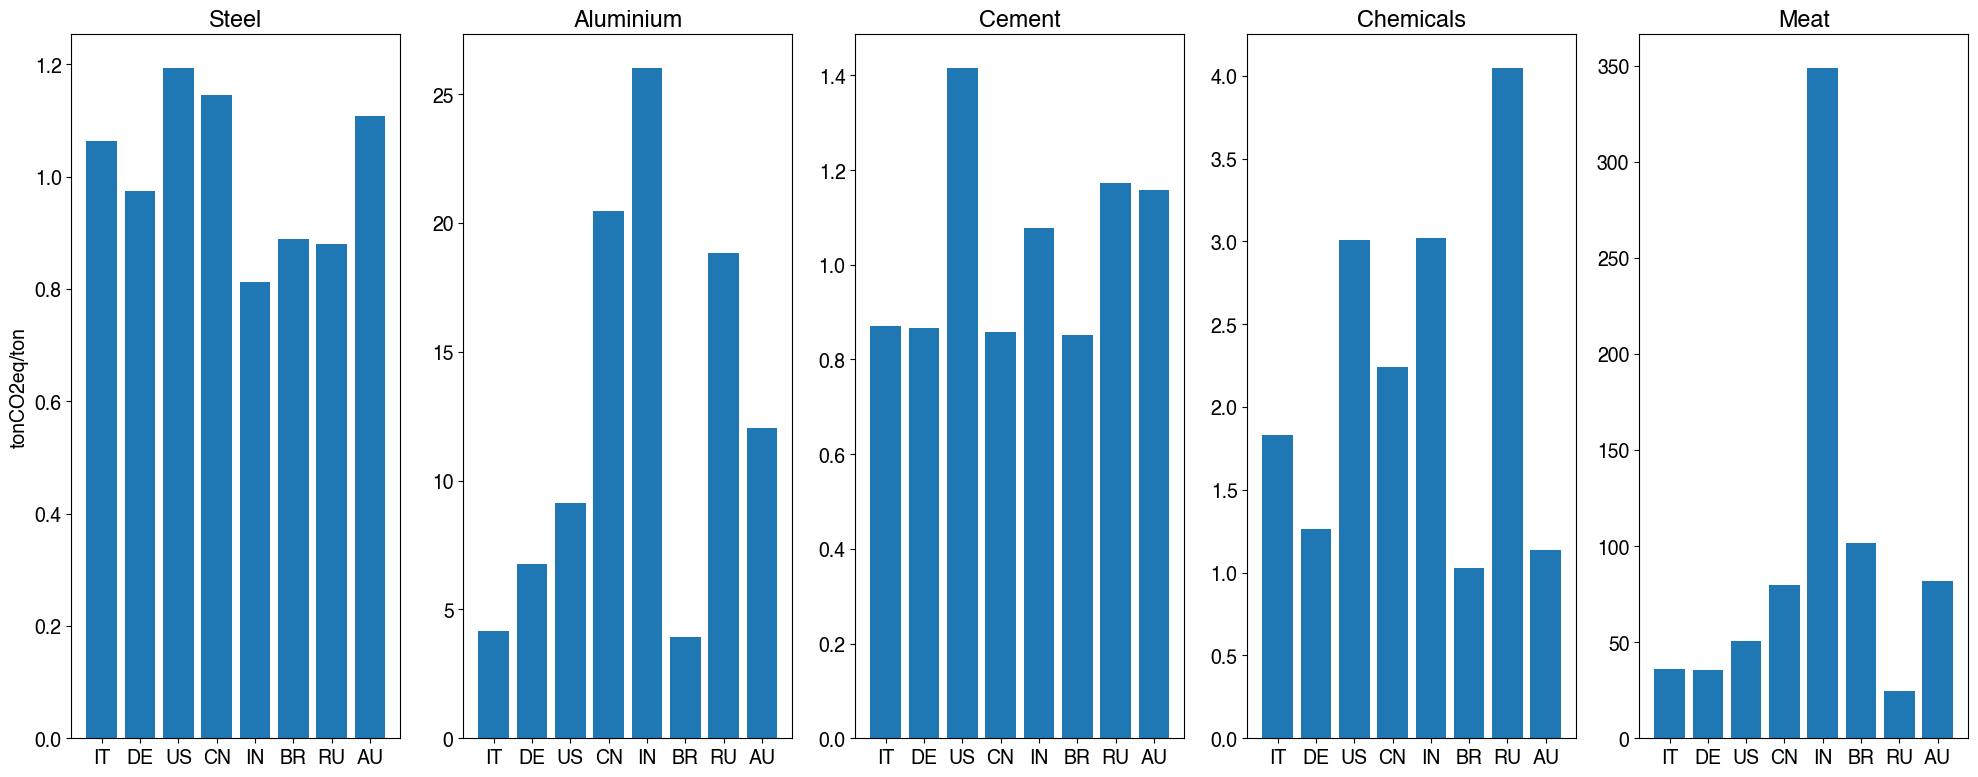

In [192]:
import matplotlib.pyplot as plt

# Get unique items
unique_items = f['Item'].unique()
regions = ['IT','DE','US','CN','IN','BR','RU','AU']

# Create a figure and subplots
fig, axs = plt.subplots(1, len(unique_items), figsize=(20, 8), sharey=False)

# Plot each item in a separate subplot
for ax, item in zip(axs, unique_items):
    item_data = f[f['Item'] == item]
    ax.bar(regions, item_data.set_index('Region').loc[regions, 'Value'])
    ax.set_title(f'{item}')
    # Set ylabel for the first subplot only
    if ax == axs[0]:
        ax.set_ylabel('tonCO2eq/ton')

# Set common x-label
# plt.xlabel('Region')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [189]:
item

'Chemicals'